# DATA CLEANING
## GOAL
### The goal of this notebook is to filter the data to make it usable for all models

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Was wir alles filtern wollen
 - [x] **time for survey taking** ->20/ 30 minutes -> 230 questions, abt 6 questions per minute, also filters just clicking.
       **NB: I set the treshold to 15 mins - Casi**
- filter rows with >20% NA --> filters out follow up questions
 --> Here we also filter all PARTY_AGENDAS-Questions
- **dont know** -> na/ filetern/ delete ppl that answer a lot of dk, row > 5% dont know weg
  **; there are 84 columns that contain at least 1 don't know; I filtered people out with 40%+ DK answers (threshold number we can still discuss! - Linus** 
- what about ppl that dont take the survey seriously and just click the **answers with patterns**? do we just accept it? can we filter this?
  - check for many same answers in ordinal questions and potentially clean them (maybe we leave it and just clean the rows that filled out the survey too fast)
  -   --> I think maybe it's better to not filter this, because if someone answers in a pattern, the randomization from the survey itself should handle this bias. I mean we still get "true" data just with higher vatiance (or noise). ANd also again I think with the 15min time-threshold this problem is mostly solved.- Linus 

- does democrat/ republican ratio change before/after cleaning #dat["PARTY_AGENDAS_rand_2016"].value_counts()
- how much data do we have left?
- data needs to work for all models -> maybe no na at all -> **dropna** #rows_with_na = dat.isna().any(axis=1).sum()
- RIEKE
The output of cleaning round 1 is found in **data/votersurvey_cleaned.parquet**

### cleaning round 2

- remove zipcodes (izip_2016)since there are almost as many zipcodes as participants 
- remove variable "PARTY_AGENDAS_rand_2016", which we had previously regardes as target variable! This variable is actually only a randomisation!
- new target variable: 'presvote16post_2016'
- remove rows that did not vote for either trump or clinton
- potentialy remove variables that ask if you favor this or this person to focus on variables asking for an attitude
The output of cleaning round 1 is found in **data/votersurvey_cleaned_noDropNA.parquet**
**NB: the NA's need to be dropped in the modeling notebooks**

### after cleaning
- pca (nice plot for the presentation, potentially aids in feature selection)
- feature selection -> correlation again (project (2) code file)
- basically all the tests and models 
- modelle fitten: random forest, deep neural network, kNN?

1. data cleaning
2. feature selection
3. model creation and training
4. repeat

In [22]:
#read data with correct NA values
dat = pd.read_csv("data/VOTER_Survey_December16_Release1.csv")
dat.replace('__NA__', np.nan, inplace=True) #correctly read in NA values
print(dat.shape)

dat.head()

/tmp/ipykernel_3029/52852683.py:2: DtypeWarning: Columns (0: votereg_fnd_baseline, 1: religpew_muslim_baseline) have mixed types. Specify dtype option on import or set low_memory=False.
  dat = pd.read_csv("data/VOTER_Survey_December16_Release1.csv")


(8000, 668)


,case_identifier,weight,PARTY_AGENDAS_rand_2016,pp_primary16_2016,pp_demprim16_2016,pp_repprim16_2016,inputstate_2016,izip_2016,votereg2_2016,votereg_f_2016,...,post_HouseCand3Name_2012,post_HouseCand3Party_2012,post_SenCand1Name_2012,post_SenCand1Party_2012,post_SenCand2Name_2012,post_SenCand2Party_2012,post_SenCand3Name_2012,post_SenCand3Party_2012,starttime_2016,endtime_2016
0,779,0.358213,Republican Party,In the Democratic primary,Hillary Clinton,NaN,California,94952,Yes,Yes,...,NaN,NaN,Shelley Berkley,Democratic,Dean Heller,Republican,NaN,NaN,29nov2016 22:59:43,29nov2016 23:28:24
1,2108,0.562867,Republican Party,In the Republican primary,NaN,Donald Trump,Arizona,85298,Yes,Yes,...,NaN,NaN,Richard Carmona,Democratic,Jeff Flake,Republican,NaN,NaN,29nov2016 15:41:28,29nov2016 18:58:28
2,2597,0.552138,Republican Party,In the Democratic primary,Hillary Clinton,NaN,Wisconsin,54904,Yes,Yes,...,NaN,NaN,Tammy Baldwin,Democratic,Tommy Thompson,Republican,NaN,NaN,29nov2016 16:08:39,29nov2016 16:32:43
3,4148,0.207591,Democratic Party,In the Democratic primary,Someone else,NaN,Oklahoma,74104,Yes,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14dec2016 18:46:33,14dec2016 19:11:20
4,4460,0.333729,Republican Party,In the Republican primary,NaN,Marco Rubio,Texas,78253,Yes,Yes,...,NaN,NaN,Paul Sadler,Democratic,Ted Cruz,Republican,NaN,NaN,01dec2016 10:17:47,01dec2016 10:59:48


### remove specific columns and rows

In [23]:
#remove columns we don't need, recognized by patterns: 2012, baseline, rnd

#initial shape
print("initial shape: ", dat.shape)

#Remove columns that contain "2012" in their names
dat = dat.loc[:, ~dat.columns.str.contains('2012')].copy()
print("drop 2012: ", dat.shape) #check how many rows remain

#remove columns that contain 'baseline' in their name (older than 2012)
dat = dat.loc[:, ~dat.columns.str.contains('baseline')].copy()
print("drop baseline: ", dat.shape) #check how many rows remain

#remove columns that contain 'rnd' in their name (randomisation order, not a question)
dat = dat.loc[:, ~dat.columns.str.contains('rnd')].copy()
print("drop randomistion orders: ", dat.shape) #check how many rows remain

# Exclude columns with more than 20% NA: for the follow up question
perc = 0.20
threshold = len(dat) * perc
dat = dat.loc[:, dat.isnull().sum() <= threshold]

print(f"drop columns with more than {perc*100}% NA values: ", dat.shape) #see final number of rows


initial shape:  (8000, 668)
drop 2012:  (8000, 638)
drop baseline:  (8000, 279)
drop randomistion orders:  (8000, 219)
drop columns with more than 20.0% NA values:  (8000, 180)


In [24]:
#remove all rows that did not vote for either clinton or trump
dat = dat[dat["presvote16post_2016"].isin(['Donald Trump', 'Hillary Clinton'])]

In [25]:
#drop columns that ask how favorable your opinion towards a person is
#or who of two person you prefer
#in order to only have columns asking for attitudes

#open question: drop inputstate as well? --> would leave it - Linus
cols_to_drop =[
    "fav_trump_2016",
    "fav_cruz_2016",
    "fav_ryan_2016",
    "fav_romn_2016",
    "fav_obama_2016",
    "fav_hrc_2016",
    "fav_sanders_2016",
    "fav_rubio_2016", 
    "Clinton_Rubio_2016",
    "Clinton_Cruz_2016",
    "Sanders_Trump_2016",
    "Sanders_Rubio_2016",
    "pid7_2016" # same question as pid3_2016
]

dat = dat.drop(columns = cols_to_drop)

presvote16post_2016                             Donald Trump  Hillary Clinton
envpoll2_2016                                                                
Don't know                                               532              300
Natural causes not related to human activities          1315              164
Pollution from human activities                          646             3039
NaN                                                      986               42


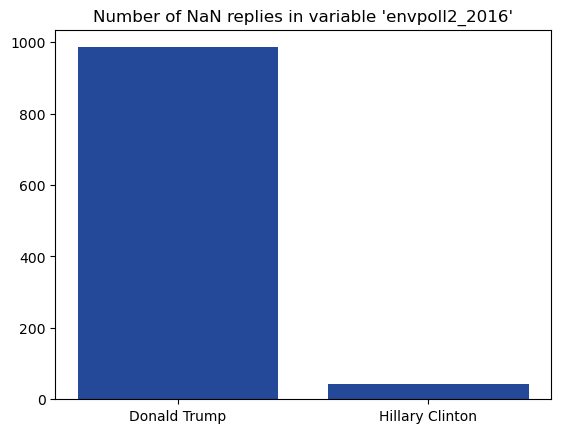

In [79]:
#plot showing why to drop 'envpoll2_2016'

#plt.bar(dat['envpoll2_2016'])
dat['envpoll2_2016'][dat["presvote16post_2016"] == "Donald Trump"].value_counts()
dat['envpoll2_2016'][dat["presvote16post_2016"] == "Hillary Clinton"].value_counts()

# Create a contingency table between 'envpoll2_2016' and another column
contingency_table = pd.crosstab(dat['envpoll2_2016'], dat["presvote16post_2016"], dropna = False)

# Display the table
print(contingency_table)

plt.bar(["Donald Trump", "Hillary Clinton"], contingency_table.iloc[3], color = "#244999")
plt.title("Number of NaN replies in variable 'envpoll2_2016'")
plt.savefig('results/eda/NaN_count_envpoll2_2016.png')
plt.show()

In [6]:
#calculate time for filling out survey and clean specific columns afterwards

#calculate time for filling out survey
dat["starttime_2016"] = pd.to_datetime(dat["starttime_2016"], format = "%d%b%Y %H:%M:%S") #format 
dat["endtime_2016"] = pd.to_datetime(dat["endtime_2016"], format = "%d%b%Y %H:%M:%S") #format

dat["time_for_survey"] = dat["endtime_2016"] - dat["starttime_2016"] #timedelta

rows_to_drop = dat["time_for_survey"] < pd.Timedelta(15, "minutes")
print("No of rows to drop: ", np.sum(rows_to_drop))#20 minutes kicks out 2700 rows, 15 minutes only 1000 rows
dat = dat[~rows_to_drop] #drop rows

# clean specific columns
dat = dat.drop(["case_identifier", 'izip_2016', "PARTY_AGENDAS_rand_2016", "weight", "starttime_2016", "endtime_2016", "time_for_survey", 'envpoll2_2016'], axis = 1) #envpoll2_2016 has many and almost exclusively trump voters that did not answer 

#print result
print("dat shape after dropping participants that took too long to fill out survey: ", dat.shape)

No of rows to drop:  845
dat shape after dropping participants that took too long to fill out survey:  (6179, 160)


In [7]:
# Don't know filtering

dk_cols = []
for col in dat.columns:
    if dat[col].isin(["Don't know"]).any():
        dk_cols.append(col)

print(f"{len(dk_cols)} columns contain 'Don't know'")
#print(dk_cols)

# How many people have how many DK in total (from 0 to 79 DK / person
dk_per_person = (dat[dk_cols] == "Don't know").sum(axis=1)
#print(dk_per_person.value_counts().sort_index())

# Who are the people that answered DK in more than 50% of DK columns (42+ out of 84)
threshold = 0.4
min_dk = len(dk_cols) * threshold

to_much_dk = dk_per_person[dk_per_person > min_dk]

print(f"People answering DK in more than {threshold * 100}% of don't know columns: {len(to_much_dk)}")
print(to_much_dk.sort_values(ascending=False))

# apply on data
print(f"before filtering DK candidats: {dat.shape}")
dat = dat.drop(index=to_much_dk.index)
print(f"after filtering DK candidats: {dat.shape}")

71 columns contain 'Don't know'
People answering DK in more than 40.0% of don't know columns: 27
2823    66
7491    65
6072    57
4672    52
4439    50
6098    49
5082    46
5143    41
5967    39
4881    38
2302    38
6488    38
6865    37
5211    36
4464    36
2532    36
7668    35
2331    33
3140    33
3973    32
6277    32
2624    31
3189    31
5208    30
3783    30
3947    29
5287    29
dtype: int64
before filtering DK candidats: (6179, 160)
after filtering DK candidats: (6152, 160)


### datetype conversions

In [8]:
#convert "feeling thermometer" columns to numeric
#some values are e.g. "75 - somewhat favorable" and need to be converted to a float - hence the slightly complicated code

#NB: I replaced NaN values with the column mean for the feeling thermometer columns
#this prevents dropping 500 additional columns in the final dat.dropna()
#however, this can be discussed and we can remove this code section

# List of columns to process (feeling thermometer columns)
thermometer_cols = [
    "ft_black_2016", "ft_white_2016", "ft_hisp_2016", "ft_asian_2016",
    "ft_muslim_2016", "ft_jew_2016", "ft_christ_2016", "ft_fem_2016",
    "ft_immig_2016", "ft_blm_2016", "ft_wallst_2016", "ft_gays_2016",
    "ft_unions_2016", "ft_police_2016", "ft_altright_2016"
]

# Extract numeric part and convert to float for each column
for col in thermometer_cols:
    dat[col] = pd.to_numeric(
        dat[col].astype(str).str.extract(r'(\d+)')[0],
        errors='coerce'  # Convert invalid parsing to NaN
    )
    col_mean = dat[col].mean()  # Compute column mean 
    dat[col] = dat[col].fillna(col_mean)  # Replace NaN with column mean

# Verify changes (optional)
#print(dat[thermometer_cols].head())

In [9]:
#save colnames and their dtypes for inspection in a csv
df_rownames_dtypes = pd.DataFrame({'colname': pd.Series(dat.columns), 
                        'dtype': dat.dtypes.values,
                                 'unique_values': dat.nunique().values})
df_rownames_dtypes.to_csv("data/df_rownames_dtypes.csv")

In [10]:
dat.info() #check 

<class 'pandas.DataFrame'>
Index: 6152 entries, 0 to 7999
Columns: 160 entries, pp_primary16_2016 to religpew_2016
dtypes: float64(15), str(145)
memory usage: 20.5 MB


In [11]:
#convert all variables with dtype "str" to categories
for i in range(len(df_rownames_dtypes["colname"])):
    colname = df_rownames_dtypes["colname"][i]
    dtype = df_rownames_dtypes["dtype"][i]
    if dtype == "str":
        dat[f'{colname}'] = dat[f'{colname}'].astype('category')

#convert zip code to category
#dat['izip_2016'] = dat['izip_2016'].astype('category')

### some checks before finishing up

In [12]:
dat.info() #correct dtypes, memory usage now 10times smaller

<class 'pandas.DataFrame'>
Index: 6152 entries, 0 to 7999
Columns: 160 entries, pp_primary16_2016 to religpew_2016
dtypes: category(145), float64(15)
memory usage: 1.6 MB


In [13]:
#update csv with final colnames and their dtypes for inspection
df_rownames_dtypes = pd.DataFrame({'colname': pd.Series(dat.columns), 
                        'dtype': dat.dtypes.values,
                                 'unique_values': dat.nunique().values})
df_rownames_dtypes.to_csv("data/df_rownames_dtypes.csv")

In [14]:
dat.head()

,pp_primary16_2016,inputstate_2016,votereg2_2016,votereg_f_2016,turnout16_2016,votemeth16_2016,presvote16post_2016,vote_for_against_2016,vote_regrets_2016,accurately_counted_2016,...,employ_2016,faminc_2016,pid3_2016,ideo5_2016,newsint_2016,pew_bornagain_2016,pew_religimp_2016,pew_churatd_2016,pew_prayer_2016,religpew_2016
0,In the Democratic primary,California,Yes,Yes,Yes,By mail,Hillary Clinton,Vote in favor,No,Very confident,...,Retired,Prefer not to say,Democrat,Moderate,Most of the time,No,Not too important,Seldom,Seldom,Roman Catholic
1,In the Republican primary,Arizona,Yes,Yes,Yes,In person before the election,Donald Trump,Vote in favor,No,Very confident,...,Permanently disabled,"$60,000 - $69,999",Republican,Conservative,Most of the time,No,Very important,More than once a week,Several times a day,Mormon
2,In the Democratic primary,Wisconsin,Yes,Yes,Yes,In person before the election,Hillary Clinton,Vote in favor,No,Not too confident,...,Retired,"$50,000 - $59,999",Independent,Moderate,Most of the time,No,Not at all important,Seldom,A few times a week,Roman Catholic
4,In the Republican primary,Texas,Yes,Yes,Yes,In person before the election,Donald Trump,Vote against opponent,No,Very confident,...,Full-time,"$40,000 - $49,999",Republican,Conservative,Most of the time,No,Very important,More than once a week,Once a day,Mormon
5,In the Democratic primary,California,Yes,Yes,Yes,By mail,Hillary Clinton,Vote in favor,No,Very confident,...,Retired,"$30,000 - $39,999",Democrat,Very liberal,Most of the time,No,Not at all important,Never,Never,Nothing in particular


In [16]:
dat["presvote16post_2016"].value_counts() #the proportion should remain the same after dropping rows

presvote16post_2016
Donald Trump       3098
Hillary Clinton    3054
Name: count, dtype: int64

### drop all rows that contain NA values and save output to parquet

In [18]:
#drop all
dat_dropna = dat.dropna()

In [19]:
print("shape after cleaning: ", dat.shape)
print("\nProportion check of target variable")
dat_dropna["presvote16post_2016"].value_counts() #still roughly the same proportion

shape after cleaning:  (6152, 160)

Proportion check of target variable


presvote16post_2016
Hillary Clinton    1760
Donald Trump       1650
Name: count, dtype: int64

**NA still need to be dropped in the model notebooks!!**

In [20]:
#save cleaned df for next steps
dat.to_parquet('data/votersurvey_cleaned_noDropNA.parquet')

#read the df with the following code: 
#df = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet')
#optional: select features identified in feature selection
#drop NA's only afterwards 
#df = df.dropna() 
